# 모델 학습
전처리 -> XGBoost 학습 -> SHAP -> 백테스팅

In [1]:
# 셀 1 - 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# 셀 2 - 데이터 로드
df = pd.read_csv('dataset_final.csv', parse_dates=['date'])
df = df.sort_values(['stock_code', 'date']).reset_index(drop=True)

print(f'shape: {df.shape}')
print(f'종목 수: {df["stock_code"].nunique()}')
print(f'기간: {df["date"].min()} ~ {df["date"].max()}')
print(f'\ntarget 분포:')
print(df['target'].value_counts())

shape: (172224, 93)
종목 수: 170
기간: 2021-12-10 00:00:00 ~ 2026-06-15 00:00:00

target 분포:
target
0    72858
1    51163
2    48203
Name: count, dtype: int64


In [3]:
# 셀 3 - 피처 컬럼 정의
exclude_cols = ['stock_code', 'stock_name', 'date', 'target']
feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f'총 피처 수: {len(feature_cols)}')
print(feature_cols)

총 피처 수: 89
['open', 'high', 'low', 'close', 'volume', 'ma10_gap', 'ma20_gap', 'ma60_gap', 'ma120_gap', 'ma_spread_5_60', 'ma_spread_10_60', 'is_uptrend', 'is_downtrend', 'ma10_break', 'ma_cross_golden', 'ma_cross_dead', 'candle_above_ma60', 'rsi_9', 'rsi_above_70', 'rsi_above_50', 'rsi_exit_70', 'rsi_touch_ma_count', 'macd', 'macd_signal', 'macd_hist', 'macd_uptrend', 'macd_above_zero', 'macd_near_zero', 'bb_pct', 'bb_width', 'bb_upper_break', 'bb_lower_support', 'ichi_above_cloud', 'ichi_below_cloud', 'ichi_in_cloud', 'cloud_green', 'cloud_thickness', 'ichi_conversion_cross', 'fib_786_support', 'fib_618_level', 'fib_500_level', 'prev_high_break', 'prev_high_fail', 'higher_high', 'higher_low', 'lower_high', 'double_bottom', 'body_ratio', 'is_bullish', 'is_bearish', 'is_doji', 'upper_wick_ratio', 'lower_wick_ratio', 'gap_up', 'gap_down', 'gap_fill_rate', 'vol_ratio_20', 'vol_spike', 'vol_up_with_price_up', 'vol_down_with_price_up', 'ma_convergence', 'short_trend_turn', 'uptrend_with_vol

In [4]:
# 3-1
# 도메인 피처 점수화 - 최종 가중치
score_weights = {
    # 최강 신호 (4점) - 승률 80%, 수익 5%+
    'macd_zero_cross':         5,

    # 강한 신호 (3점) - 승률 55%+, 수익 3%+
    'double_bottom_confirm':   3,
    'ma60_support':            3,
    'uptrend_with_volume':     3,
    'ichi_cloud_breakout':     3,

    # 보통 신호 (2점) - 승률 50%+, 수익 2%+
    'vol_surge_bullish':       2,
    'bb_squeeze':              2,

    # 제외 (성과 나쁨)
    # rsi_macd_buy:  승률 44%, 수익 0.09% -> 제거
    # rsi_cooling:   승률 40%, 수익 -0.66% -> 제거
    # convergence_vol_surge: 승률 46%, 수익 -0.28% -> 제거
}

score_weights = {k: v for k, v in score_weights.items() if k in df.columns}

df['domain_score'] = sum(
    df[feat] * weight
    for feat, weight in score_weights.items()
).astype(int)

print(f'domain_score 분포:')
print(df['domain_score'].describe())
print(f'\n점수별 분포:\n{df["domain_score"].value_counts().sort_index()}')

domain_score 분포:
count    172224.000000
mean          1.593820
std           2.449459
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          19.000000
Name: domain_score, dtype: float64

점수별 분포:
domain_score
0     95259
2     42549
3     12923
4        54
5      8115
6      4174
7       867
8      4505
9       743
10      825
11     1154
12       29
13      499
14      153
15       40
16      280
18       50
19        5
Name: count, dtype: int64


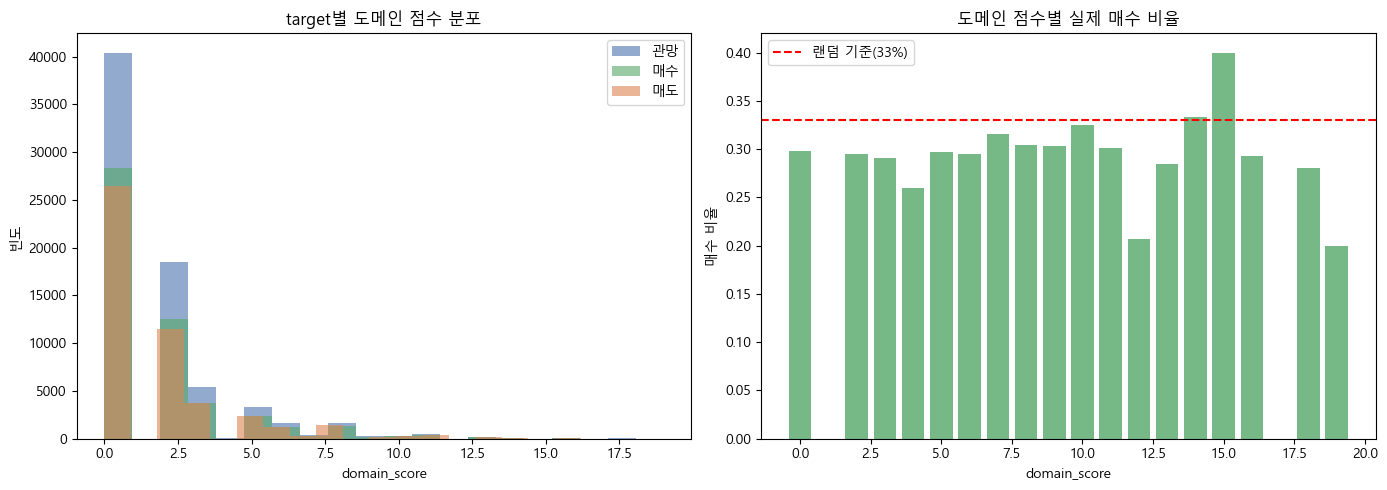

=== 도메인 점수별 매수 비율 ===
    점수      매수비율      랜덤대비      평가
----------------------------------------
     0점    29.8%     -3.2%  ▼ 미달
     2점    29.5%     -3.5%  ▼ 미달
     3점    29.1%     -3.9%  ▼ 미달
     4점    25.9%     -7.1%  ▼ 미달
     5점    29.7%     -3.3%  ▼ 미달
     6점    29.5%     -3.5%  ▼ 미달
     7점    31.6%     -1.4%  ▼ 미달
     8점    30.5%     -2.5%  ▼ 미달
     9점    30.3%     -2.7%  ▼ 미달
    10점    32.5%     -0.5%  ▼ 미달
    11점    30.2%     -2.8%  ▼ 미달
    12점    20.7%    -12.3%  ▼ 미달
    13점    28.5%     -4.5%  ▼ 미달
    14점    33.3%     +0.3%  △ 보통
    15점    40.0%     +7.0%  ★ 우수
    16점    29.3%     -3.7%  ▼ 미달
    18점    28.0%     -5.0%  ▼ 미달
    19점    20.0%    -13.0%  ▼ 미달

=== 클래스별 도메인 점수 분포 ===
관망  평균: 1.54점  중앙값: 0점  최대: 19점
매수  평균: 1.60점  중앙값: 0점  최대: 19점
매도  평균: 1.67점  중앙값: 0점  최대: 18점


In [5]:
# 3-2
# 도메인 점수 시각화
colors = ['#4C72B0', '#55A868', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for t, label, color in zip([0,1,2], ['관망','매수','매도'], colors):
    axes[0].hist(df[df['target']==t]['domain_score'],
                 bins=20, alpha=0.6, label=label, color=color)
axes[0].set_title('target별 도메인 점수 분포')
axes[0].set_xlabel('domain_score')
axes[0].set_ylabel('빈도')
axes[0].legend()

score_buy_rate = df.groupby('domain_score').apply(
    lambda x: (x['target'] == 1).mean()
).reset_index()
score_buy_rate.columns = ['score', 'buy_rate']

axes[1].bar(score_buy_rate['score'], score_buy_rate['buy_rate'],
            color='#55A868', alpha=0.8)
axes[1].axhline(0.33, color='red', linestyle='--', label='랜덤 기준(33%)')
axes[1].set_title('도메인 점수별 실제 매수 비율')
axes[1].set_xlabel('domain_score')
axes[1].set_ylabel('매수 비율')
axes[1].legend()

plt.tight_layout()
plt.show()

# 텍스트 출력 추가
print('=== 도메인 점수별 매수 비율 ===')
print(f'{"점수":>6}  {"매수비율":>8}  {"랜덤대비":>8}  {"평가":>6}')
print('-' * 40)
for _, row in score_buy_rate.iterrows():
    score    = int(row['score'])
    buy_rate = row['buy_rate']
    diff     = buy_rate - 0.33
    grade    = '★ 우수' if buy_rate >= 0.40 else ('△ 보통' if buy_rate >= 0.33 else '▼ 미달')
    print(f'{score:>6}점  {buy_rate:>7.1%}  {diff:>+8.1%}  {grade}')

print(f'\n=== 클래스별 도메인 점수 분포 ===')
for t, label in zip([0, 1, 2], ['관망', '매수', '매도']):
    sub = df[df['target'] == t]['domain_score']
    print(f'{label}  평균: {sub.mean():.2f}점  중앙값: {sub.median():.0f}점  최대: {sub.max():.0f}점')

In [6]:
# 시장 지표 강화
# vix_trend: 0 = 하락(안정), 1 = 상승(공포)
# nasdaq_trend: 1 = 상승, 0 = 하락

# 나스닥 상승 + VIX 안정
df['nasdaq_vix_bull'] = (
    (df['nasdaq_change'] > 0) & (df['vix_change'] < 0)
).astype(int)

# 나스닥 + 코스피 동반 상승
df['market_dual_up'] = (
    (df['nasdaq_trend'] == 1) & (df['kospi_trend'] == 1)
).astype(int)

# 환율 하락 + 나스닥 상승
df['usd_down_nasdaq_up'] = (
    (df['usd_krw_change'] < 0) & (df['nasdaq_change'] > 0)
).astype(int)

# VIX 안정(0) + 나스닥 상승(1)  <- 조건 수정
df['low_fear_bull'] = (
    (df['vix_trend'] == 0) & (df['nasdaq_trend'] == 1)
).astype(int)

print('시장 지표 파생 피처 추가 완료')
print(f'nasdaq_vix_bull:    {df["nasdaq_vix_bull"].sum():,}건')
print(f'market_dual_up:     {df["market_dual_up"].sum():,}건')
print(f'usd_down_nasdaq_up: {df["usd_down_nasdaq_up"].sum():,}건')
print(f'low_fear_bull:      {df["low_fear_bull"].sum():,}건')

시장 지표 파생 피처 추가 완료
nasdaq_vix_bull:    75,752건
market_dual_up:     82,299건
usd_down_nasdaq_up: 44,224건
low_fear_bull:      84,193건


In [7]:
# 3-4
# feature_cols 재정의 (새 피처 포함)
exclude_cols = ['stock_code', 'stock_name', 'date', 'target']
feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f'총 피처 수 (새 파생 피처 포함): {len(feature_cols)}')
print([c for c in feature_cols if c in [
    'domain_score', 'nasdaq_vix_bull', 'market_dual_up',
    'usd_down_nasdaq_up', 'low_fear_bull'
]])

총 피처 수 (새 파생 피처 포함): 94
['domain_score', 'nasdaq_vix_bull', 'market_dual_up', 'usd_down_nasdaq_up', 'low_fear_bull']


In [8]:
# feature_cols에 domain_score 추가
feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f'총 피처 수 (domain_score 포함): {len(feature_cols)}')

총 피처 수 (domain_score 포함): 94


In [9]:
# 셀 4 - 결측치 확인 및 처리
print('[결측치 확인]')
null_counts = df[feature_cols].isnull().sum()
print(null_counts[null_counts > 0])

df[feature_cols] = df[feature_cols].fillna(method='ffill').fillna(0)

print(f'\n결측치 처리 후: {df[feature_cols].isnull().sum().sum()}개')

[결측치 확인]
Series([], dtype: int64)

결측치 처리 후: 0개


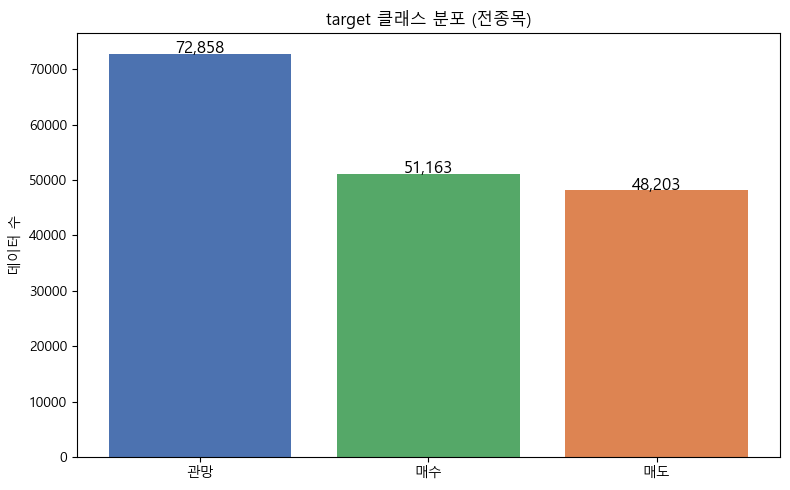

=== target 분포 ===
관망: 72,858건 (42.3%)
매수: 51,163건 (29.7%)
매도: 48,203건 (28.0%)


In [10]:
# 셀 5 - target 분포 시각화
target_map = {0: '관망', 1: '매수', 2: '매도'}
colors = ['#4C72B0', '#55A868', '#DD8452']

target_counts = df['target'].map(target_map).value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(target_counts.index, target_counts.values, color=colors)
for bar, val in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=12)
plt.title('target 클래스 분포 (전종목)')
plt.ylabel('데이터 수')
plt.tight_layout()
plt.show()

print('=== target 분포 ===')
for label, val in zip(target_counts.index, target_counts.values):
    print(f'{label}: {val:,}건 ({val/len(df)*100:.1f}%)')

In [11]:
# 셀 6 - 워크포워드 학습/테스트 분리
dates = df['date'].sort_values().unique()
split_idx  = int(len(dates) * 0.8)
split_date = dates[split_idx]

df_train = df[df['date'] < split_date].copy()
df_test  = df[df['date'] >= split_date].copy()

print(f'학습 기간: {df_train["date"].min()} ~ {df_train["date"].max()}')
print(f'테스트 기간: {df_test["date"].min()} ~ {df_test["date"].max()}')
print(f'학습 데이터: {df_train.shape}')
print(f'테스트 데이터: {df_test.shape}')
print(f'\ndomain_score 확인: {"있음" if "domain_score" in df_test.columns else "없음"}')

학습 기간: 2021-12-10 00:00:00 ~ 2025-07-22 00:00:00
테스트 기간: 2025-07-23 00:00:00 ~ 2026-06-15 00:00:00
학습 데이터: (136324, 98)
테스트 데이터: (35900, 98)

domain_score 확인: 있음


In [12]:
# 셀 7 - X, y 분리 + 스케일링
X_train = df_train[feature_cols]
y_train = df_train['target']
X_test  = df_test[feature_cols]
y_test  = df_test['target']

# domain_score 기반 샘플 가중치 (점수 높을수록 더 중요하게 학습)
base_weight = 1.0
score_col   = df_train['domain_score'].values
sample_weight_train = base_weight + score_col * 0.5

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print(f'X_train: {X_train_scaled.shape}')
print(f'X_test:  {X_test_scaled.shape}')
print(f'\n학습 target 분포:\n{y_train.value_counts()}')
print(f'\n샘플 가중치 분포:\n{pd.Series(sample_weight_train).describe()}')

X_train: (136324, 94)
X_test:  (35900, 94)

학습 target 분포:
target
0    59633
1    38739
2    37952
Name: count, dtype: int64

샘플 가중치 분포:
count    136324.000000
mean          1.782848
std           1.215983
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          10.500000
dtype: float64


[SMOTE 적용 전]
target
0    59633
1    38739
2    37952
Name: count, dtype: int64

[SMOTE 적용 후]
target
1    59633
0    59633
2    59633
Name: count, dtype: int64


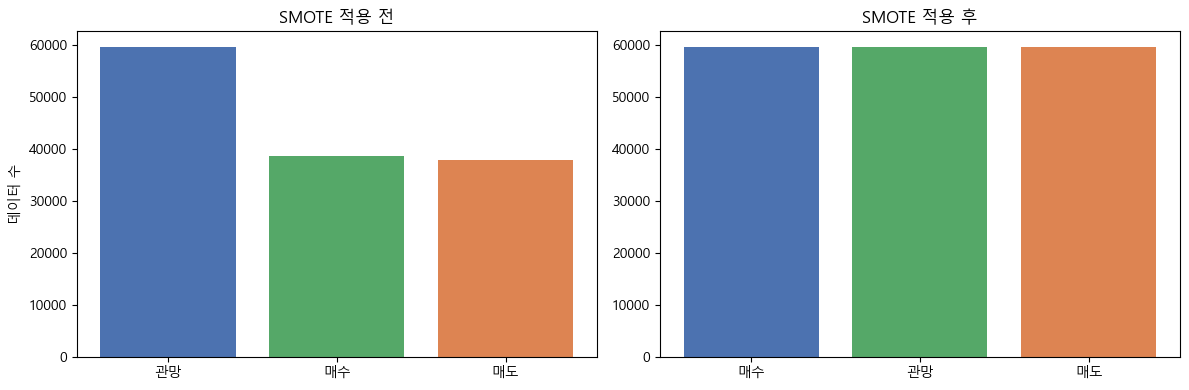


=== SMOTE 요약 ===
적용 전 총 샘플: 136,324건
적용 후 총 샘플: 178,899건
증가량: +42,575건

가중치 적용 샘플: 136,324개 / 전체: 178,899개
가중치 범위: 1.0 ~ 10.5


In [13]:
# 셀 8 - SMOTE (반드시 분리 후 X_train에만 적용)
print('[SMOTE 적용 전]')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# SMOTE로 생성된 샘플은 기본 가중치 1.0
# 원본 샘플만 domain_score 가중치 적용
n_original  = len(X_train_scaled)
n_resampled = len(X_train_res)

sample_weight_res = np.ones(n_resampled)
sample_weight_res[:n_original] = sample_weight_train  # 원본만 가중치 적용

print('\n[SMOTE 적용 후]')
print(pd.Series(y_train_res).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
before = pd.Series(y_train).map(target_map).value_counts()
after  = pd.Series(y_train_res).map(target_map).value_counts()

axes[0].bar(before.index, before.values, color=colors)
axes[0].set_title('SMOTE 적용 전')
axes[0].set_ylabel('데이터 수')

axes[1].bar(after.index, after.values, color=colors)
axes[1].set_title('SMOTE 적용 후')

plt.tight_layout()
plt.show()

print('\n=== SMOTE 요약 ===')
print(f'적용 전 총 샘플: {len(X_train_scaled):,}건')
print(f'적용 후 총 샘플: {len(X_train_res):,}건')
print(f'증가량: +{len(X_train_res) - len(X_train_scaled):,}건')
print(f'\n가중치 적용 샘플: {n_original:,}개 / 전체: {n_resampled:,}개')
print(f'가중치 범위: {sample_weight_res.min():.1f} ~ {sample_weight_res.max():.1f}')

In [14]:
# 셀 9 - XGBoost 모델 학습
model = XGBClassifier(
    n_estimators=2000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=0.6,
    min_child_weight=20,
    reg_alpha=1.0,
    reg_lambda=5.0,
    eval_metric=['mlogloss', 'merror'],
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train_res, y_train_res,
    sample_weight=sample_weight_res,
    eval_set=[
        (X_train_res, y_train_res),
        (X_test_scaled, y_test),
    ],
    early_stopping_rounds=200,
    verbose=100
)

print(f'최적 트리 수: {model.best_iteration}')
print('학습 완료')

[0]	validation_0-mlogloss:1.09831	validation_0-merror:0.59504	validation_1-mlogloss:1.09842	validation_1-merror:0.62457
[100]	validation_0-mlogloss:1.07409	validation_0-merror:0.56118	validation_1-mlogloss:1.08368	validation_1-merror:0.59788
[200]	validation_0-mlogloss:1.05886	validation_0-merror:0.54767	validation_1-mlogloss:1.07858	validation_1-merror:0.59460
[300]	validation_0-mlogloss:1.04634	validation_0-merror:0.53641	validation_1-mlogloss:1.07688	validation_1-merror:0.59836
[386]	validation_0-mlogloss:1.03542	validation_0-merror:0.52613	validation_1-mlogloss:1.07695	validation_1-merror:0.59786
최적 트리 수: 186
학습 완료


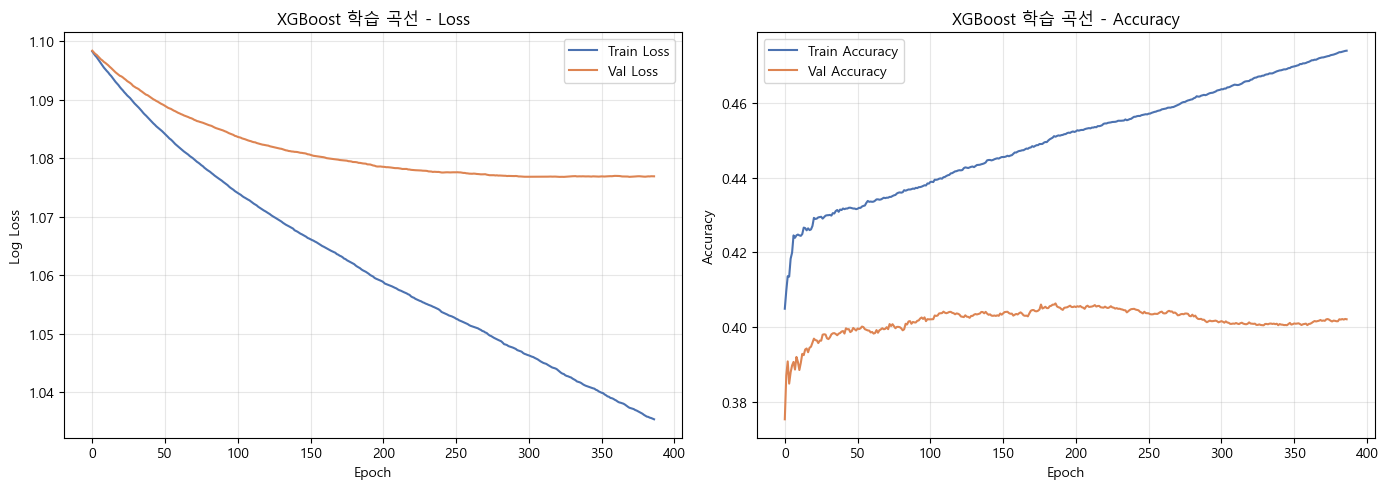

=== 학습 곡선 요약 ===
최적 트리 수:       186
최종 Train Loss:    1.03542
최종 Val Loss:      1.07695
최종 Train Acc:     0.4739 (47.39%)
최종 Val Acc:       0.4021 (40.21%)
과적합 갭:          7.17%p


In [15]:
# 셀 10 - 학습 곡선
results = model.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results['validation_0']['mlogloss'], label='Train Loss', color='#4C72B0')
axes[0].plot(results['validation_1']['mlogloss'], label='Val Loss',   color='#DD8452')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('XGBoost 학습 곡선 - Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

train_acc = [1 - e for e in results['validation_0']['merror']]
val_acc   = [1 - e for e in results['validation_1']['merror']]

axes[1].plot(train_acc, label='Train Accuracy', color='#4C72B0')
axes[1].plot(val_acc,   label='Val Accuracy',   color='#DD8452')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('XGBoost 학습 곡선 - Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('=== 학습 곡선 요약 ===')
print(f'최적 트리 수:       {model.best_iteration}')
print(f'최종 Train Loss:    {results["validation_0"]["mlogloss"][-1]:.5f}')
print(f'최종 Val Loss:      {results["validation_1"]["mlogloss"][-1]:.5f}')
print(f'최종 Train Acc:     {train_acc[-1]:.4f} ({train_acc[-1]*100:.2f}%)')
print(f'최종 Val Acc:       {val_acc[-1]:.4f} ({val_acc[-1]*100:.2f}%)')
print(f'과적합 갭:          {(train_acc[-1] - val_acc[-1])*100:.2f}%p')

In [16]:
# 셀 11 - 모델 성능 평가
y_pred = model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score (macro): {f1_score(y_test, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['관망', '매수', '매도']))

Accuracy: 0.4064
F1 Score (macro): 0.4027

              precision    recall  f1-score   support

          관망       0.46      0.45      0.45     13225
          매수       0.39      0.40      0.40     12424
          매도       0.35      0.36      0.36     10251

    accuracy                           0.41     35900
   macro avg       0.40      0.40      0.40     35900
weighted avg       0.41      0.41      0.41     35900



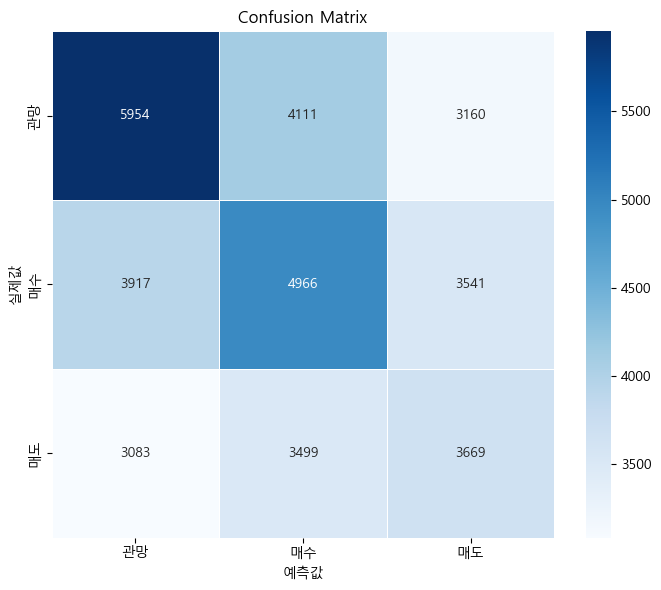

=== Confusion Matrix 분석 ===
관망: 5,954/13,225 정답 (45.0%)
매수: 4,966/12,424 정답 (40.0%)
매도: 3,669/10,251 정답 (35.8%)

전체 정확도: 14,589/35,900 (40.64%)


In [17]:
# 셀 12 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['관망', '매수', '매도'],
    yticklabels=['관망', '매수', '매도'],
    linewidths=0.5
)
plt.title('Confusion Matrix')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()

print('=== Confusion Matrix 분석 ===')
labels = ['관망', '매수', '매도']
total = cm.sum()
for i, label in enumerate(labels):
    correct  = cm[i, i]
    actual   = cm[i].sum()
    recall   = correct / actual * 100
    print(f'{label}: {correct:,}/{actual:,} 정답 ({recall:.1f}%)')
print(f'\n전체 정확도: {np.trace(cm):,}/{total:,} ({np.trace(cm)/total*100:.2f}%)')

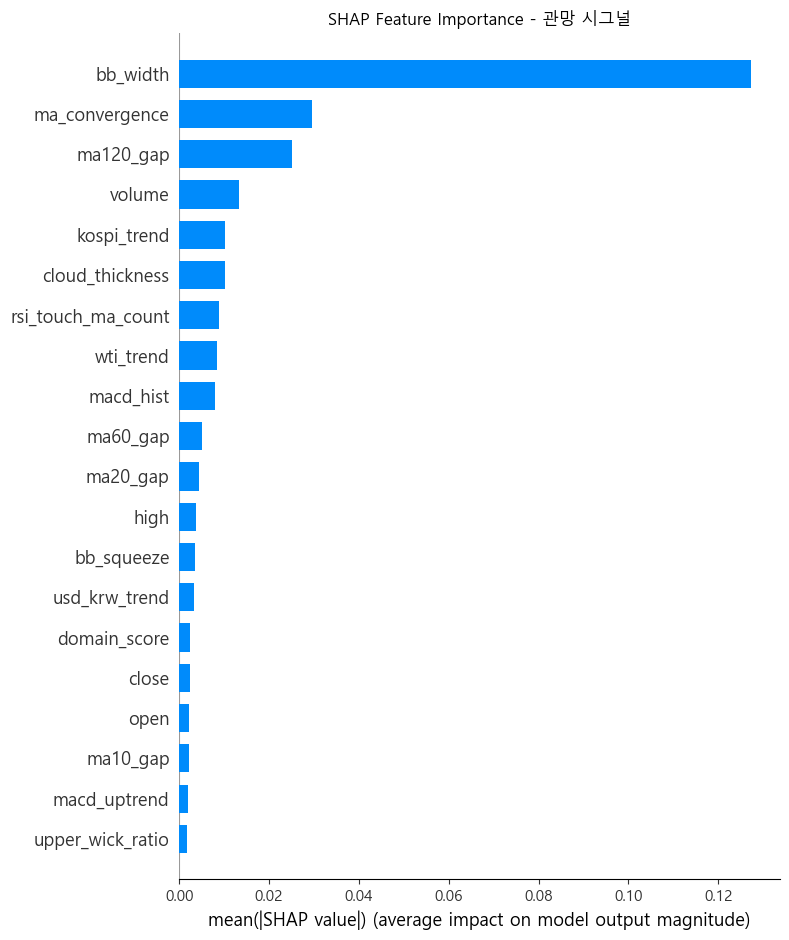


=== SHAP Feature Importance - 관망 시그널 (상위 20개) ===
  순위  피처명                                    중요도
--------------------------------------------------
   1위  bb_width                        0.127368
   2위  ma_convergence                  0.029559
   3위  ma120_gap                       0.025190
   4위  volume                          0.013330
   5위  kospi_trend                     0.010184
   6위  cloud_thickness                 0.010150
   7위  rsi_touch_ma_count              0.008907
   8위  wti_trend                       0.008335
   9위  macd_hist                       0.007982
  10위  ma60_gap                        0.004959
  11위  ma20_gap                        0.004377
  12위  high                            0.003652
  13위  bb_squeeze                      0.003395
  14위  usd_krw_trend                   0.003236
  15위  domain_score                    0.002463
  16위  close                           0.002335
  17위  open                            0.002165
  18위  ma10_gap                  

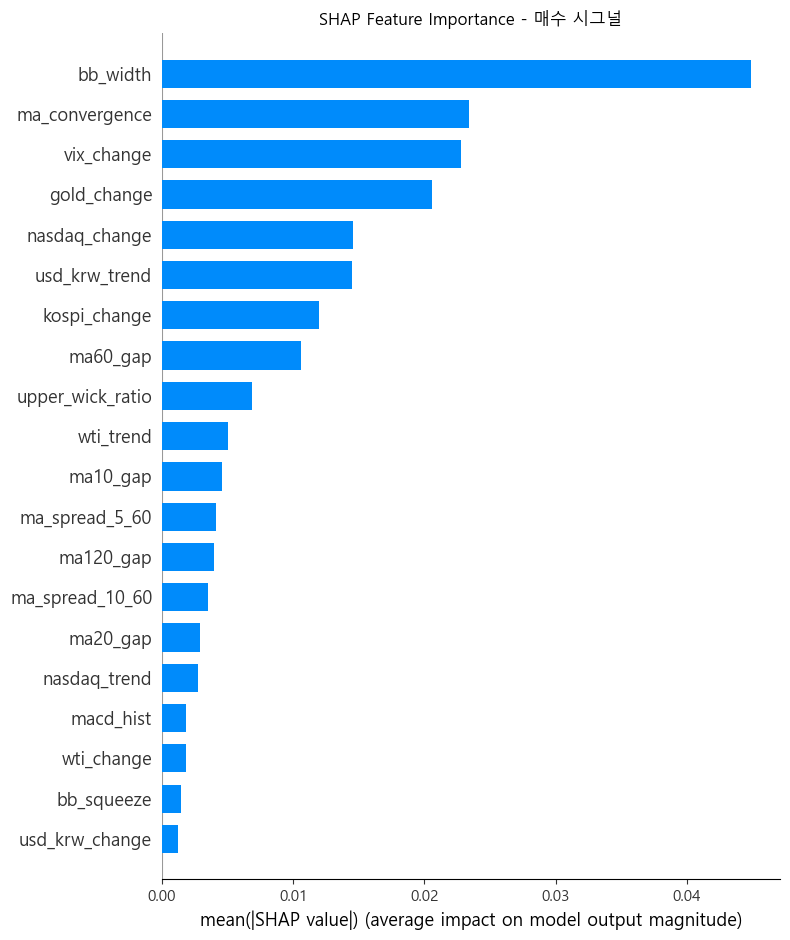


=== SHAP Feature Importance - 매수 시그널 (상위 20개) ===
  순위  피처명                                    중요도
--------------------------------------------------
   1위  bb_width                        0.044841
   2위  ma_convergence                  0.023387
   3위  vix_change                      0.022800
   4위  gold_change                     0.020555
   5위  nasdaq_change                   0.014516
   6위  usd_krw_trend                   0.014444
   7위  kospi_change                    0.011963
   8위  ma60_gap                        0.010559
   9위  upper_wick_ratio                0.006830
  10위  wti_trend                       0.005053
  11위  ma10_gap                        0.004608
  12위  ma_spread_5_60                  0.004130
  13위  ma120_gap                       0.003980
  14위  ma_spread_10_60                 0.003515
  15위  ma20_gap                        0.002931
  16위  nasdaq_trend                    0.002755
  17위  macd_hist                       0.001853
  18위  wti_change                

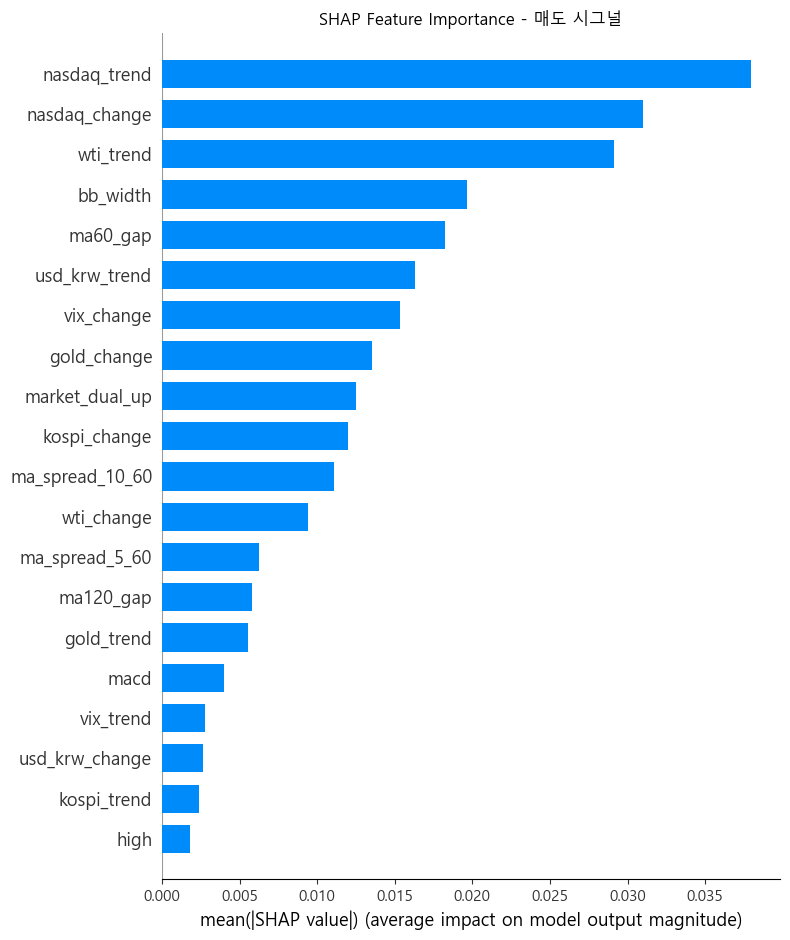


=== SHAP Feature Importance - 매도 시그널 (상위 20개) ===
  순위  피처명                                    중요도
--------------------------------------------------
   1위  nasdaq_trend                    0.037928
   2위  nasdaq_change                   0.030987
   3위  wti_trend                       0.029112
   4위  bb_width                        0.019678
   5위  ma60_gap                        0.018256
   6위  usd_krw_trend                   0.016288
   7위  vix_change                      0.015328
   8위  gold_change                     0.013514
   9위  market_dual_up                  0.012493
  10위  kospi_change                    0.012012
  11위  ma_spread_10_60                 0.011105
  12위  wti_change                      0.009413
  13위  ma_spread_5_60                  0.006251
  14위  ma120_gap                       0.005826
  15위  gold_trend                      0.005545
  16위  macd                            0.004010
  17위  vix_trend                       0.002748
  18위  usd_krw_change            

In [18]:
# 셀 13 - SHAP 피처 중요도 (클래스별)
# XGBoost 버전에 따라 shap_values 구조가 다름
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

class_names = ['관망', '매수', '매도']

for i, name in enumerate(class_names):
    if isinstance(shap_values, list):
        sv = shap_values[i]
    else:
        sv = shap_values[:, :, i]

    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        sv, X_test_scaled,
        plot_type='bar', max_display=20, show=False
    )
    plt.title(f'SHAP Feature Importance - {name} 시그널')
    plt.tight_layout()
    plt.show()

    # 텍스트 출력
    mean_shap = np.abs(sv).mean(axis=0)
    shap_df   = pd.Series(mean_shap, index=feature_cols).sort_values(ascending=False)

    print(f'\n=== SHAP Feature Importance - {name} 시그널 (상위 20개) ===')
    print(f'{"순위":>4}  {"피처명":<30}  {"중요도":>10}')
    print('-' * 50)
    for rank, (feat, val) in enumerate(shap_df.head(20).items(), 1):
        print(f'{rank:>4}위  {feat:<30}  {val:.6f}')

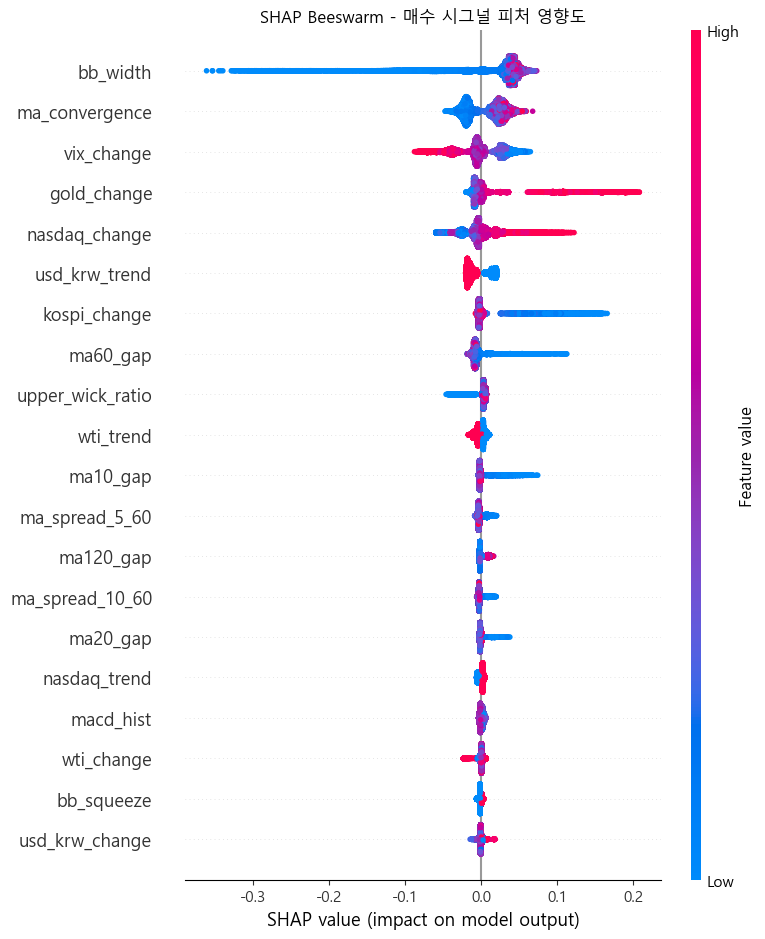


=== SHAP Beeswarm - 매수 시그널 상위 20개 ===
  순위  피처명                                    중요도  방향
------------------------------------------------------------
   1위  bb_width                        0.044841  ▲ 매수에 긍정
   2위  ma_convergence                  0.023387  ▲ 매수에 긍정
   3위  vix_change                      0.022800  ▼ 매수에 부정
   4위  gold_change                     0.020555  ▲ 매수에 긍정
   5위  nasdaq_change                   0.014516  ▼ 매수에 부정
   6위  usd_krw_trend                   0.014444  ▼ 매수에 부정
   7위  kospi_change                    0.011963  ▲ 매수에 긍정
   8위  ma60_gap                        0.010559  ▼ 매수에 부정
   9위  upper_wick_ratio                0.006830  ▼ 매수에 부정
  10위  wti_trend                       0.005053  ▼ 매수에 부정
  11위  ma10_gap                        0.004608  ▲ 매수에 긍정
  12위  ma_spread_5_60                  0.004130  ▼ 매수에 부정
  13위  ma120_gap                       0.003980  ▲ 매수에 긍정
  14위  ma_spread_10_60                 0.003515  ▼ 매수에 부정
  15위  ma20_gap                    

In [19]:
# 셀 14 - SHAP beeswarm (매수 시그널 기준)
if isinstance(shap_values, list):
    sv_buy = shap_values[1]
else:
    sv_buy = shap_values[:, :, 1]

plt.figure(figsize=(10, 10))
shap.summary_plot(
    sv_buy, X_test_scaled,
    max_display=20, show=False
)
plt.title('SHAP Beeswarm - 매수 시그널 피처 영향도')
plt.tight_layout()
plt.show()

# 텍스트 출력
mean_shap_buy = np.abs(sv_buy).mean(axis=0)
shap_buy_df   = pd.Series(mean_shap_buy, index=feature_cols).sort_values(ascending=False)

print('\n=== SHAP Beeswarm - 매수 시그널 상위 20개 ===')
print(f'{"순위":>4}  {"피처명":<30}  {"중요도":>10}  {"방향"}')
print('-' * 60)

# 양수/음수 방향도 같이 출력 (평균 SHAP 값 기준)
mean_shap_signed = sv_buy.mean(axis=0)
for rank, feat in enumerate(shap_buy_df.head(20).index, 1):
    val      = shap_buy_df[feat]
    signed   = mean_shap_signed[feature_cols.index(feat)]
    direction = '▲ 매수에 긍정' if signed > 0 else '▼ 매수에 부정'
    print(f'{rank:>4}위  {feat:<30}  {val:.6f}  {direction}')

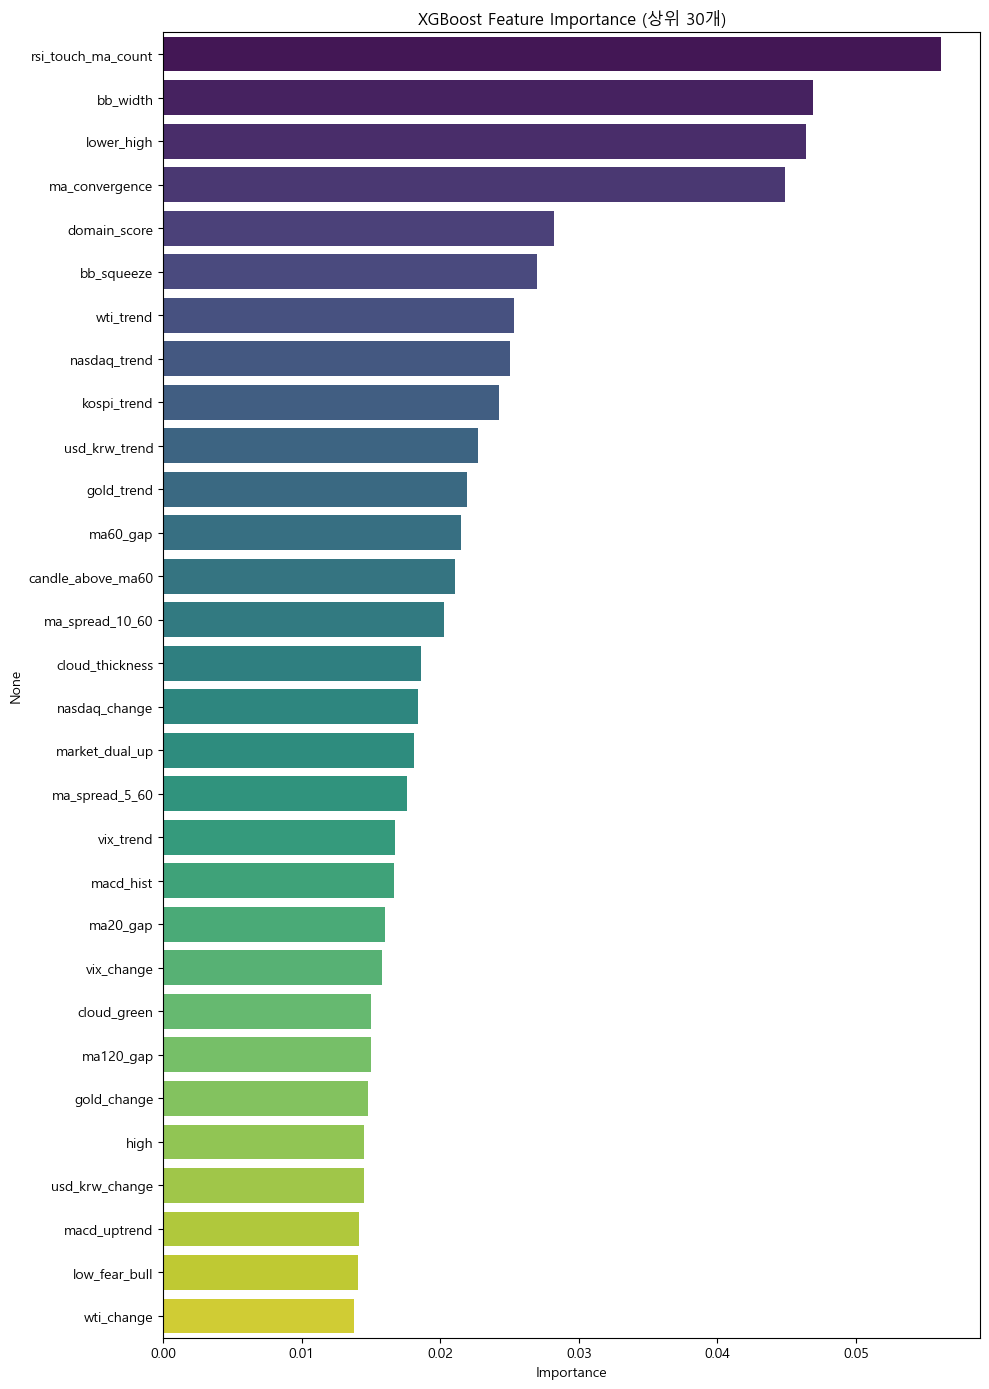

=== XGBoost Feature Importance 상위 20개 ===
  순위  피처명                                    중요도
--------------------------------------------------
   1위  rsi_touch_ma_count              0.05615
   2위  bb_width                        0.04692
   3위  lower_high                      0.04637
   4위  ma_convergence                  0.04488
   5위  domain_score                    0.02824
   6위  bb_squeeze                      0.02699
   7위  wti_trend                       0.02530
   8위  nasdaq_trend                    0.02501
   9위  kospi_trend                     0.02427
  10위  usd_krw_trend                   0.02270
  11위  gold_trend                      0.02190
  12위  ma60_gap                        0.02150
  13위  candle_above_ma60               0.02106
  14위  ma_spread_10_60                 0.02030
  15위  cloud_thickness                 0.01863
  16위  nasdaq_change                   0.01841
  17위  market_dual_up                  0.01807
  18위  ma_spread_5_60                  0.01761
  19위  vix_t

In [20]:
# 셀 15 - XGBoost Feature Importance
fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 14))
sns.barplot(x=fi.values[:30], y=fi.index[:30], palette='viridis')
plt.title('XGBoost Feature Importance (상위 30개)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('=== XGBoost Feature Importance 상위 20개 ===')
print(f'{"순위":>4}  {"피처명":<30}  {"중요도":>10}')
print('-' * 50)
for rank, (feat, val) in enumerate(fi.head(20).items(), 1):
    print(f'{rank:>4}위  {feat:<30}  {val:.5f}')

In [21]:
# 셀 16 - 백테스팅
df_bt = df_test.copy().reset_index(drop=True)
df_bt['pred'] = y_pred

proba = model.predict_proba(X_test_scaled)
df_bt['proba_관망'] = proba[:, 0]
df_bt['proba_매수'] = proba[:, 1]
df_bt['proba_매도'] = proba[:, 2]

df_bt['signal'] = (
    (df_bt['pred'] == 1) &
    (df_bt['proba_매수'] > df_bt['proba_관망']) &
    (df_bt['proba_매수'] > df_bt['proba_매도']) &
    (
        (df_bt['macd_zero_cross'] == 1) |
        (df_bt['domain_score'] >= 3)
    )
).astype(int)

df_bt = df_bt.sort_values(['stock_code', 'date']).reset_index(drop=True)
df_bt['return_5d'] = df_bt.groupby('stock_code')['close'].transform(
    lambda x: x.shift(-5) / x - 1
)

df_signal = df_bt[df_bt['signal'] == 1].dropna(subset=['return_5d'])

print('=== 백테스팅 기본 결과 ===')
print(f'총 매수 시그널: {len(df_signal)}건')
print(f'평균 수익률:    {df_signal["return_5d"].mean():.4f} ({df_signal["return_5d"].mean()*100:.2f}%)')
print(f'승률:           {(df_signal["return_5d"] > 0).mean():.4f} ({(df_signal["return_5d"] > 0).mean()*100:.2f}%)')
print(f'최대 수익률:    {df_signal["return_5d"].max():.4f} ({df_signal["return_5d"].max()*100:.2f}%)')
print(f'최대 손실률:    {df_signal["return_5d"].min():.4f} ({df_signal["return_5d"].min()*100:.2f}%)')
print(f'중앙값 수익률:  {df_signal["return_5d"].median():.4f} ({df_signal["return_5d"].median()*100:.2f}%)')

=== 백테스팅 기본 결과 ===
총 매수 시그널: 2348건
평균 수익률:    0.0280 (2.80%)
승률:           0.5707 (57.07%)
최대 수익률:    0.9549 (95.49%)
최대 손실률:    -0.3116 (-31.16%)
중앙값 수익률:  0.0127 (1.27%)


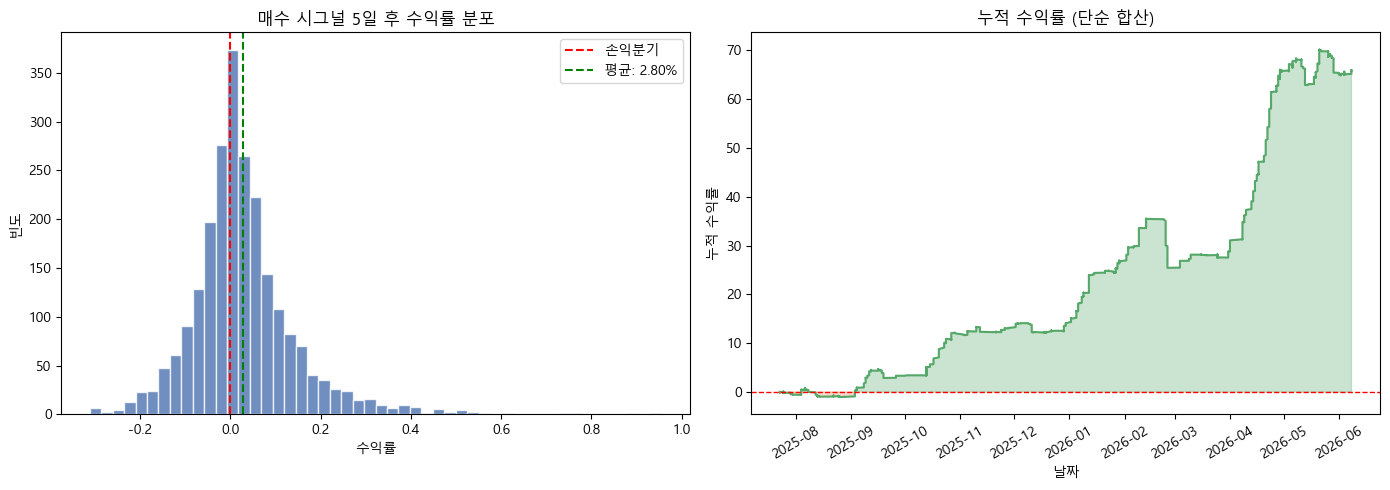

=== 수익률 분포 분석 ===
평균:     2.80%
중앙값:   1.27%
표준편차: 11.64%
최대:     95.49%
최소:     -31.16%

구간별 분포:
  -5%미만     :   445건 (19.0%)
  -5~-3%    :   180건 (7.7%)
  -3~-2%    :   111건 (4.7%)
  -2~0%     :   272건 (11.6%)
  0~2%      :   256건 (10.9%)
  2~3%      :   109건 (4.6%)
  3~5%      :   199건 (8.5%)
  5%이상      :   776건 (33.0%)


In [22]:
# 셀 17 수정
df_cum = df_signal.sort_values('date').copy()
df_cum['cum_return'] = df_cum['return_5d'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_signal['return_5d'], bins=50, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='손익분기')
axes[0].axvline(df_signal['return_5d'].mean(), color='green', linestyle='--',
                linewidth=1.5, label=f'평균: {df_signal["return_5d"].mean():.2%}')
axes[0].set_title('매수 시그널 5일 후 수익률 분포')
axes[0].set_xlabel('수익률')
axes[0].set_ylabel('빈도')
axes[0].legend()

axes[1].plot(df_cum['date'], df_cum['cum_return'], color='#55A868', linewidth=1.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].fill_between(df_cum['date'], df_cum['cum_return'], 0,
                     where=df_cum['cum_return'] >= 0, alpha=0.3, color='#55A868')
axes[1].fill_between(df_cum['date'], df_cum['cum_return'], 0,
                     where=df_cum['cum_return'] < 0, alpha=0.3, color='#DD8452')
axes[1].set_title('누적 수익률 (단순 합산)')
axes[1].set_xlabel('날짜')
axes[1].set_ylabel('누적 수익률')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('=== 수익률 분포 분석 ===')
print(f'평균:     {df_signal["return_5d"].mean():.2%}')
print(f'중앙값:   {df_signal["return_5d"].median():.2%}')
print(f'표준편차: {df_signal["return_5d"].std():.2%}')
print(f'최대:     {df_signal["return_5d"].max():.2%}')
print(f'최소:     {df_signal["return_5d"].min():.2%}')
print(f'\n구간별 분포:')
bins = [-1, -0.05, -0.03, -0.02, 0, 0.02, 0.03, 0.05, 1]
labels = ['-5%미만', '-5~-3%', '-3~-2%', '-2~0%', '0~2%', '2~3%', '3~5%', '5%이상']
df_signal['return_bin'] = pd.cut(df_signal['return_5d'], bins=bins, labels=labels)
for label, cnt in df_signal['return_bin'].value_counts().sort_index().items():
    pct = cnt / len(df_signal) * 100
    print(f'  {label:<10}: {cnt:>5}건 ({pct:.1f}%)')

In [23]:
# 셀 18 - MDD + 성과 요약
cum_returns = df_cum['cum_return'].values
rolling_max = np.maximum.accumulate(cum_returns)
mdd         = (cum_returns - rolling_max).min()

print('=== 백테스팅 성과 요약 ===')
print(f'총 시그널 수:    {len(df_signal)}건')
print(f'승률:            {(df_signal["return_5d"] > 0).mean():.2%}')
print(f'평균 수익률:     {df_signal["return_5d"].mean():.2%}')
print(f'누적 수익률:     {df_cum["cum_return"].iloc[-1]:.2%}')
print(f'MDD:             {mdd:.2%}')
print(f'+3% 이상 비율:  {(df_signal["return_5d"] > 0.03).mean():.2%}')
print(f'-3% 이하 비율:  {(df_signal["return_5d"] < -0.03).mean():.2%}')
print(f'+2% 이상 비율:  {(df_signal["return_5d"] > 0.02).mean():.2%}')
print(f'-2% 이하 비율:  {(df_signal["return_5d"] < -0.02).mean():.2%}')

=== 백테스팅 성과 요약 ===
총 시그널 수:    2348건
승률:            57.07%
평균 수익률:     2.80%
누적 수익률:     6585.27%
MDD:             -1006.10%
+3% 이상 비율:  41.52%
-3% 이하 비율:  26.62%
+2% 이상 비율:  46.17%
-2% 이하 비율:  31.35%


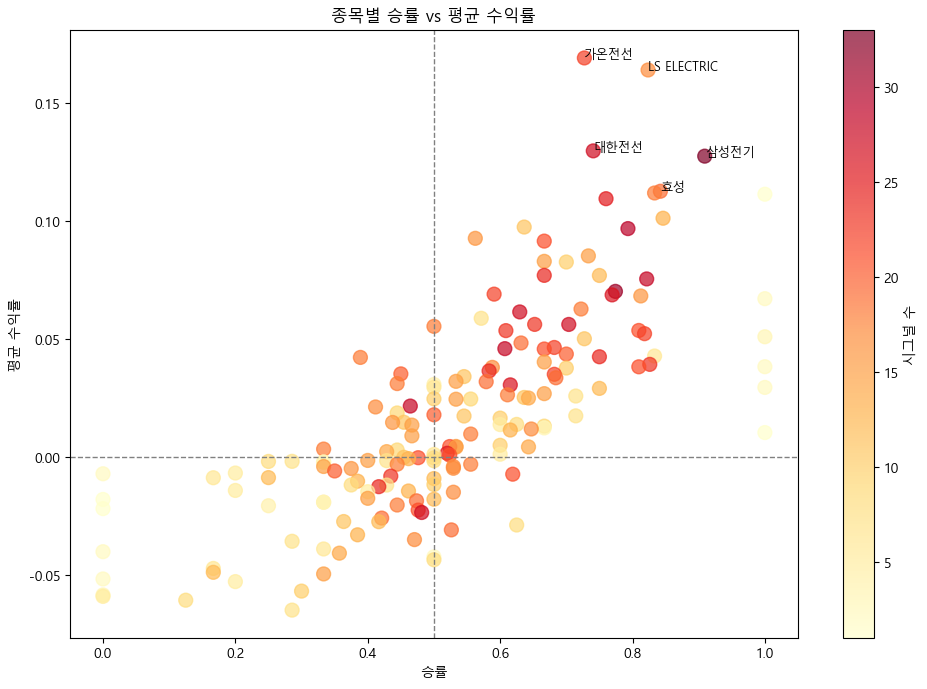

=== 종목별 성과 상위 10개 ===
 stock_code  stock_name  시그널수    평균수익률       승률     최대수익      최대손실
        500        가온전선    22 0.169026 0.727273 0.954939 -0.307921
      10120 LS ELECTRIC    17 0.163924 0.823529 0.904274 -0.110497
       1440        대한전선    27 0.129665 0.740741 0.416569 -0.170124
       9150        삼성전기    33 0.127421 0.909091 0.766611 -0.187220
       4800          효성    19 0.112554 0.842105 0.391092 -0.109032
      66570        LG전자    18 0.111818 0.833333 0.560675 -0.054336
      30200          KT     1 0.111298 1.000000 0.111298  0.111298
     103590        일진전기    25 0.109404 0.760000 0.493264 -0.056338
        150          두산    13 0.101124 0.846154 0.320534 -0.036295
      47040        대우건설    11 0.097392 0.636364 0.378906 -0.148741

=== 전체 통계 ===
분석 종목 수:     169개
승률 50% 이상:    102개 (60.4%)
평균수익 플러스:  101개 (59.8%)
최고 승률 종목:   KT (100.0%)
최고 수익 종목:   가온전선 (16.9%)


In [24]:
# 셀 19 - 종목별 성과 분석
stock_perf = df_signal.groupby(['stock_code', 'stock_name']).agg(
    시그널수=('return_5d', 'count'),
    평균수익률=('return_5d', 'mean'),
    승률=('return_5d', lambda x: (x > 0).mean()),
    최대수익=('return_5d', 'max'),
    최대손실=('return_5d', 'min'),
).reset_index().sort_values('평균수익률', ascending=False)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    stock_perf['승률'], stock_perf['평균수익률'],
    c=stock_perf['시그널수'], cmap='YlOrRd', s=100, alpha=0.7
)
plt.colorbar(scatter, label='시그널 수')
plt.axhline(0,   color='gray', linestyle='--', linewidth=1)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel('승률')
plt.ylabel('평균 수익률')
plt.title('종목별 승률 vs 평균 수익률')

for _, row in stock_perf.head(5).iterrows():
    plt.annotate(row['stock_name'], (row['승률'], row['평균수익률']),
                 fontsize=9, ha='left')

plt.tight_layout()
plt.show()

print('=== 종목별 성과 상위 10개 ===')
print(stock_perf.head(10).to_string(index=False))
print(f'\n=== 전체 통계 ===')
print(f'분석 종목 수:     {len(stock_perf)}개')
print(f'승률 50% 이상:    {(stock_perf["승률"] >= 0.5).sum()}개 ({(stock_perf["승률"] >= 0.5).mean()*100:.1f}%)')
print(f'평균수익 플러스:  {(stock_perf["평균수익률"] > 0).sum()}개 ({(stock_perf["평균수익률"] > 0).mean()*100:.1f}%)')
print(f'최고 승률 종목:   {stock_perf.loc[stock_perf["승률"].idxmax(), "stock_name"]} ({stock_perf["승률"].max():.1%})')
print(f'최고 수익 종목:   {stock_perf.loc[stock_perf["평균수익률"].idxmax(), "stock_name"]} ({stock_perf["평균수익률"].max():.1%})')

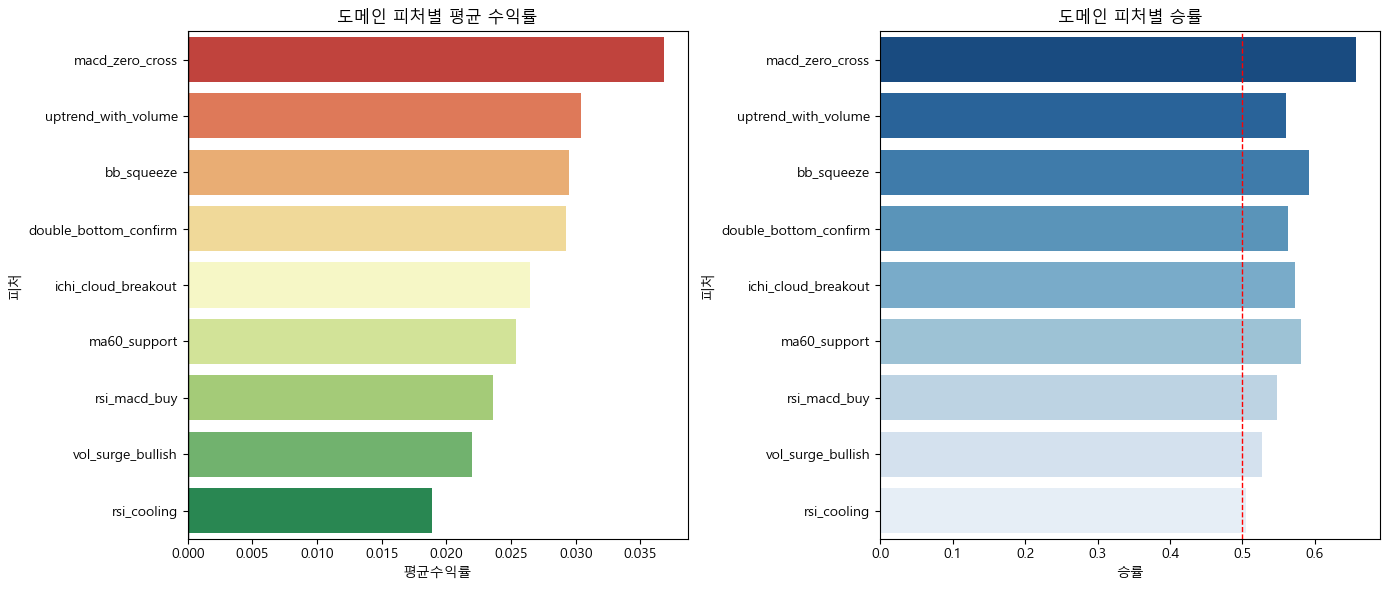

=== 도메인 피처별 성과 ===
피처                                시그널수       평균수익률        승률  평가
----------------------------------------------------------------------
macd_zero_cross                    137건      3.68%   65.69%  ★ 우수
uptrend_with_volume                792건      3.04%   56.06%  △ 보통
bb_squeeze                         444건      2.95%   59.23%  △ 보통
double_bottom_confirm             1417건      2.93%   56.25%  △ 보통
ichi_cloud_breakout                515건      2.65%   57.28%  △ 보통
ma60_support                       460건      2.54%   58.04%  △ 보통
rsi_macd_buy                       568건      2.36%   54.75%  △ 보통
vol_surge_bullish                  480건      2.20%   52.71%  △ 보통
rsi_cooling                         95건      1.89%   50.53%  △ 보통


In [25]:
# 셀 20 - 도메인 파생변수 유효성 검증
domain_features = [
    'uptrend_with_volume', 'ma60_support', 'rsi_cooling',
    'bb_squeeze', 'ichi_cloud_breakout', 'macd_zero_cross',
    'double_bottom_confirm', 'rsi_macd_buy', 'vol_surge_bullish'
]
domain_features = [f for f in domain_features if f in df_bt.columns]

results_list = []
for feat in domain_features:
    mask = (df_bt['signal'] == 1) & (df_bt[feat] == 1)
    sub  = df_bt[mask].dropna(subset=['return_5d'])
    if len(sub) < 5:
        continue
    results_list.append({
        '피처':       feat,
        '시그널수':   len(sub),
        '평균수익률': sub['return_5d'].mean(),
        '승률':       (sub['return_5d'] > 0).mean(),
    })

df_domain_perf = pd.DataFrame(results_list).sort_values('평균수익률', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=df_domain_perf, x='평균수익률', y='피처', palette='RdYlGn', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('도메인 피처별 평균 수익률')

sns.barplot(data=df_domain_perf, x='승률', y='피처', palette='Blues_r', ax=axes[1])
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1)
axes[1].set_title('도메인 피처별 승률')

plt.tight_layout()
plt.show()

print('=== 도메인 피처별 성과 ===')
print(f'{"피처":<30}  {"시그널수":>6}  {"평균수익률":>10}  {"승률":>8}  {"평가"}')
print('-' * 70)
for _, row in df_domain_perf.iterrows():
    grade = '★ 우수' if row['승률'] >= 0.6 and row['평균수익률'] >= 0.03 else \
            ('△ 보통' if row['승률'] >= 0.5 else '▼ 미달')
    print(f'{row["피처"]:<30}  {int(row["시그널수"]):>6}건  '
          f'{row["평균수익률"]:>9.2%}  {row["승률"]:>7.2%}  {grade}')

In [28]:
# 셀 21 - 종목코드 확인 후 수정
print(df_bt['stock_code'].dtype)
print(df_bt['stock_code'].unique()[:10])

# 숫자면 정수로, 문자면 문자로
target_code = 5930   # 숫자형인 경우
# target_code = '005930'  # 문자형인 경우
df_ss = df_bt[df_bt['stock_code'] == target_code].sort_values('date').copy()
print(f'삼성전자 데이터: {len(df_ss)}행')

int64
[100 150 155 240 500 660 720 810 880 990]
삼성전자 데이터: 213행


In [29]:
# 셀 21 - 삼성전자 시그널 차트
target_code = '005930'
df_ss = df_bt[df_bt['stock_code'] == target_code].sort_values('date').copy()

if len(df_ss) == 0:
    print(f'종목코드 {target_code} 데이터 없음')
    print(f'사용 가능한 종목코드 샘플:')
    print(df_bt['stock_code'].unique()[:10])
else:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    axes[0].plot(df_ss['date'], df_ss['close'], color='black', linewidth=1, label='종가')
    buy_mask  = df_ss['pred'] == 1
    sell_mask = df_ss['pred'] == 2
    axes[0].scatter(df_ss[buy_mask]['date'],  df_ss[buy_mask]['close'],
                    color='#55A868', marker='^', s=80, zorder=5, label='매수 시그널')
    axes[0].scatter(df_ss[sell_mask]['date'], df_ss[sell_mask]['close'],
                    color='#DD8452', marker='v', s=80, zorder=5, label='매도 시그널')
    axes[0].set_title('삼성전자 - AI 매수/매도 시그널')
    axes[0].set_ylabel('주가')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_ss['date'], df_ss['rsi_9'], color='purple', linewidth=1)
    axes[1].axhline(70, color='red',   linestyle='--', linewidth=1, label='과열(70)')
    axes[1].axhline(50, color='gray',  linestyle='--', linewidth=1, label='중립(50)')
    axes[1].axhline(30, color='green', linestyle='--', linewidth=1, label='과매도(30)')
    axes[1].set_ylabel('RSI')
    axes[1].set_ylim(0, 100)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    vol_colors = ['#55A868' if c > o else '#DD8452'
                  for c, o in zip(df_ss['close'], df_ss['open'])]
    axes[2].bar(df_ss['date'], df_ss['volume'], color=vol_colors, width=1, alpha=0.7)
    axes[2].set_ylabel('거래량')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 텍스트 분석
    ss_signal = df_ss[df_ss['signal'] == 1].dropna(subset=['return_5d'])
    print('=== 삼성전자 시그널 분석 ===')
    print(f'테스트 기간:    {df_ss["date"].min().date()} ~ {df_ss["date"].max().date()}')
    print(f'시작 주가:      {df_ss["close"].iloc[0]:,.0f}원')
    print(f'종료 주가:      {df_ss["close"].iloc[-1]:,.0f}원')
    print(f'기간 수익률:    {(df_ss["close"].iloc[-1]/df_ss["close"].iloc[0]-1):.2%}')
    print(f'\n매수 시그널:    {buy_mask.sum()}건')
    print(f'매도 시그널:    {sell_mask.sum()}건')
    if len(ss_signal) > 0:
        print(f'\n시그널 성과:')
        print(f'  승률:       {(ss_signal["return_5d"] > 0).mean():.2%}')
        print(f'  평균수익률: {ss_signal["return_5d"].mean():.2%}')
        print(f'  시그널 수:  {len(ss_signal)}건')
    else:
        print('\n필터링된 매수 시그널 없음')

종목코드 005930 데이터 없음
사용 가능한 종목코드 샘플:
[100 150 155 240 500 660 720 810 880 990]


In [27]:
# 셀 22 - 모델 저장 (버전 자동 증가 + 성과 정보 포함)
import os
import glob

save_dir = r'C:\Users\human3_05\Desktop\programs\RichClub\model\hyerim\results'
os.makedirs(save_dir, exist_ok=True)

# 기존 버전 확인해서 다음 버전 번호 계산
existing = glob.glob(os.path.join(save_dir, 'xgb_model_v*.pkl'))
if existing:
    versions = [int(f.split('_v')[1].split('_')[0]) for f in existing]
    next_version = max(versions) + 1
else:
    next_version = 1

version_str = f'v{next_version}'

# 성과 지표 계산
acc      = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred, average='macro')
win_rate = (df_signal['return_5d'] > 0).mean()
avg_ret  = df_signal['return_5d'].mean()
signals  = len(df_signal)

# 파일명에 성과 정보 포함
# 예: xgb_model_v3_acc40_f139_win56_ret264_sig5907.pkl
info_str = (
    f'acc{int(acc*100)}'
    f'_f1{int(f1*100)}'
    f'_win{int(win_rate*100)}'
    f'_ret{int(avg_ret*100)}'
    f'_sig{signals}'
)

model_filename  = f'xgb_model_{version_str}_{info_str}.pkl'
scaler_filename = f'scaler_{version_str}.pkl'

joblib.dump(model,  os.path.join(save_dir, model_filename))
joblib.dump(scaler, os.path.join(save_dir, scaler_filename))

print(f'모델 저장 완료')
print(f'버전:       {version_str}')
print(f'파일명:     {model_filename}')
print(f'경로:       {save_dir}')
print(f'---')
print(f'Accuracy:   {acc:.2%}')
print(f'F1 Score:   {f1:.2%}')
print(f'승률:       {win_rate:.2%}')
print(f'평균수익률: {avg_ret:.2%}')
print(f'시그널수:   {signals}건')

모델 저장 완료
버전:       v6
파일명:     xgb_model_v6_acc40_f140_win57_ret2_sig2348.pkl
경로:       C:\Users\human3_05\Desktop\programs\RichClub\model\hyerim\results
---
Accuracy:   40.64%
F1 Score:   40.27%
승률:       57.07%
평균수익률: 2.80%
시그널수:   2348건
